<div class="alert alert-block alert-success">
<center><b>DATA SCIENCE :</b></center>
<center><b>Cluster and Prediction</b></center>
</div>

# 0.- Librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import pointbiserialr
from scipy.stats import kruskal

import xgboost as xgb
from xgboost import plot_importance

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

<div class="alert alert-block alert-success">
<center><b>DATOS :</b></center>
</div>

# 1.- Datos

In [2]:
Tabla = pd.read_csv("C:/Users/guy3h/Downloads/dataset_ventas.csv")

<span style="color: green;">
<b>Valores Duplicados

In [3]:
Tabla.duplicated().sum()

0

<span style="color: green;">
<b>Valores Faltantes

In [4]:
Tabla.isna().sum()

ID Producto              0
ID Tienda                0
Fecha de Venta           0
Cantidad Vendida         0
Precio Unitario          0
Categoría de Producto    0
Ubicación de Tienda      0
Promoción o Descuento    0
Estacionalidad           0
Método de Pago           0
Nivel de Inventario      0
dtype: int64

<span style="color: green;">
<b>Renombrar Columnas

In [5]:
Datos = Tabla.copy()

In [6]:
Datos.rename(columns={ "ID Producto": "ProductoId",
                       "ID Tienda" : "TiendaId",
                       "Fecha de Venta" : "FechaVenta",
                       "Cantidad Vendida" : "CantidadVendida",
                       "Precio Unitario" : "PrecioUnitario",
                       "Categoría de Producto" : "CategoriaProducto",
                       "Ubicación de Tienda" : "UbicacionTienda",
                       "Promoción o Descuento" : "PromocionDescuento",
                       "Estacionalidad" : "Estacionalidad",
                       "Método de Pago" : "MetodoPago",
                       "Nivel de Inventario" : "NivelInventario" 
                       }, 
             inplace=True)

In [7]:
Datos.head()

,ProductoId,TiendaId,FechaVenta,CantidadVendida,PrecioUnitario,CategoriaProducto,UbicacionTienda,PromocionDescuento,Estacionalidad,MetodoPago,NivelInventario
0,Producto_43,Tienda_2,2023-02-13,81,498.48,Deportes,Zona Este,1,1,Efectivo,10
1,Producto_22,Tienda_1,2023-04-19,25,204.46,Juguetes,Zona Norte,0,1,Crédito,100
2,Producto_27,Tienda_6,2022-05-29,13,253.30,Alimentos,Zona Este,1,0,Crédito,100
3,Producto_6,Tienda_6,2022-08-15,67,134.23,Electrónica,Zona Norte,0,1,Efectivo,50
4,Producto_1,Tienda_5,2023-02-02,21,329.80,Alimentos,Zona Este,1,0,Efectivo,300


<span style="color: green;">
<b>Tipo de Datos en cada columna

In [8]:
Datos['FechaVenta'] = pd.to_datetime(Datos['FechaVenta'], format='%Y-%m-%d')
Datos.dtypes

ProductoId                    object
TiendaId                      object
FechaVenta            datetime64[ns]
CantidadVendida                int64
PrecioUnitario               float64
CategoriaProducto             object
UbicacionTienda               object
PromocionDescuento             int64
Estacionalidad                 int64
MetodoPago                    object
NivelInventario                int64
dtype: object

<div class="alert alert-block alert-success">
<center><b>EXPLORACIÓN :</b></center>
</div>

# 2.- Análisis Exploratorio

In [9]:
Datos[['CantidadVendida','PrecioUnitario','PromocionDescuento','Estacionalidad','NivelInventario']].describe().round(2)

,CantidadVendida,PrecioUnitario,PromocionDescuento,Estacionalidad,NivelInventario
count,10000.00,10000.00,10000.0,10000.0,10000.00
mean,50.78,252.43,0.5,0.5,134.08
std,28.96,143.90,0.5,0.5,158.70
min,1.00,5.10,0.0,0.0,5.00
25%,26.00,128.38,0.0,0.0,20.00
50%,51.00,252.47,1.0,1.0,50.00
75%,76.00,377.96,1.0,1.0,200.00
max,100.00,499.98,1.0,1.0,500.00


<span style="color: green;">
<b>Valores Únicos

In [10]:
print( 'Numero de Tiendas =',Datos['TiendaId'].nunique() )
print( 'Numero de Producto =',Datos['ProductoId'].nunique() )

Numero de Tiendas = 10
Numero de Producto = 50


## 2.0- Granularidad : Tienda - Producto

<span style="color: green;">
<b> Veamos el caso de la Tienda 01 - Producto 01

In [11]:
Datos[ (Datos['TiendaId']=='Tienda_1') & (Datos['ProductoId']=='Producto_1') ].sort_values(by='FechaVenta').head() 

,ProductoId,TiendaId,FechaVenta,CantidadVendida,PrecioUnitario,CategoriaProducto,UbicacionTienda,PromocionDescuento,Estacionalidad,MetodoPago,NivelInventario
2996,Producto_1,Tienda_1,2022-02-05,2,349.00,Hogar,Zona Este,1,1,Crédito,5
7645,Producto_1,Tienda_1,2022-03-26,90,78.18,Ropa,Zona Este,0,1,Crédito,500
9486,Producto_1,Tienda_1,2022-04-18,94,215.85,Electrónica,Zona Norte,1,1,Crédito,200
603,Producto_1,Tienda_1,2022-04-26,53,353.74,Ropa,Zona Oeste,0,1,Crédito,200
9155,Producto_1,Tienda_1,2022-06-11,29,51.32,Electrónica,Zona Este,0,0,Tarjeta,300


## 2.1- CategoriaProducto , UbicacionTienda

$\blacksquare$ Descartamos estas 2 columnas porque un Producto pertenece a una sola Categoria, y una Tienda tiene una sola Ubicación.

## 2.2- PrecioUnitario

In [12]:
T1P1 = Datos[ (Datos['TiendaId']=='Tienda_1') & (Datos['ProductoId']=='Producto_1') ].sort_values(by='FechaVenta') 
PrecioUnit = T1P1[['CantidadVendida', 'PrecioUnitario']]

In [13]:
xi = PrecioUnit['CantidadVendida']
yi = PrecioUnit['PrecioUnitario']

xi = sm.add_constant(xi)
model = sm.OLS(yi,xi).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         PrecioUnitario   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.053
Method:                 Least Squares   F-statistic:                   0.08772
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.771
Time:                        16:46:06   Log-Likelihood:                -117.33
No. Observations:                  19   AIC:                             238.7
Df Residuals:                      17   BIC:                             240.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             287.7791     55.533      5.182      0.000     170.614     404.944
CantidadVendida    -0.2852      0.963     -0.296      0.771      -2.317       1.746
==============================================================================
Omnibus:                        1.414   Durbin-Watson:                   2.141
Prob(Omnibus):                  0.493   Jarque-Bera (JB):                1.133
Skew:                          -0.400   Prob(JB):                        0.568
Kurtosis:                       2.110   Cond. No.                         114.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

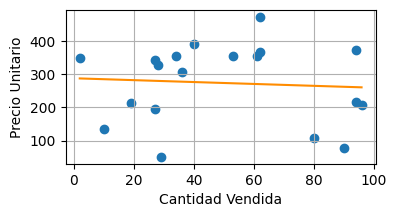

In [14]:
plt.rcParams['figure.figsize'] = [4,2] 
plt.xlabel("Cantidad Vendida")
plt.ylabel("Precio Unitario")
plt.scatter(PrecioUnit['CantidadVendida'], PrecioUnit['PrecioUnitario'])

a,b = PrecioUnit['CantidadVendida'].min(), PrecioUnit['CantidadVendida'].max()
plt.plot([a,b], 
         [ model.params[1]*a+model.params[0], 
           model.params[1]*b+model.params[0] ], 
         c='darkorange')
plt.grid()

$\blacksquare$ Parece que el Precio varia de manera inversamente proporcional a la Cantidad Vendida, para esta Tienda. Pero fijándonos en la <b>$R^2$</b>, podemos afirmar que la relación lineal entre ambas variables no es estadisticamente significativa. <br>
<br>
Por lo cual, descartamos una relación entre el Precio y la Cantidad Vendida.

## 2.3- PromociónDescuento

In [15]:
PromDesc = T1P1[['CantidadVendida', 'PromocionDescuento']]

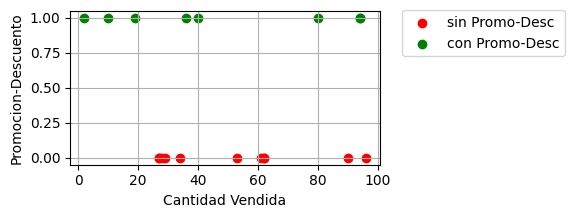

In [16]:
plt.xlabel("Cantidad Vendida")
plt.ylabel("Promocion-Descuento")

plt.rcParams['figure.figsize'] = [4,2] 
plt.scatter(PromDesc[PromDesc['PromocionDescuento']==0]['CantidadVendida'],
            PromDesc[PromDesc['PromocionDescuento']==0]['PromocionDescuento'], 
            label='sin Promo-Desc', c='red')
plt.scatter(PromDesc[PromDesc['PromocionDescuento']==1]['CantidadVendida'],
            PromDesc[PromDesc['PromocionDescuento']==1]['PromocionDescuento'], 
            label='con Promo-Desc', c='green')

plt.legend(bbox_to_anchor=(1.05, 1.05))
plt.grid()

<span style="color: green;">
<b>Prueba del Punto Biserial

In [17]:
pointbiserialr(PromDesc['CantidadVendida'], PromDesc['PromocionDescuento'])

SignificanceResult(statistic=-0.08178266399352825, pvalue=0.7392555984528354)

$\blacksquare$ El valor de la prueba nos da un <b>p-value</b> igual a 0.73. Por lo cual no se rechaza la hipótesis nula. Por lo tanto no existe una relación suficiente entre la Cantidad Vendida y las Promociones-Descuento.

## 2.4- Estacionalidad

In [18]:
Estacion = T1P1[['CantidadVendida', 'Estacionalidad']]

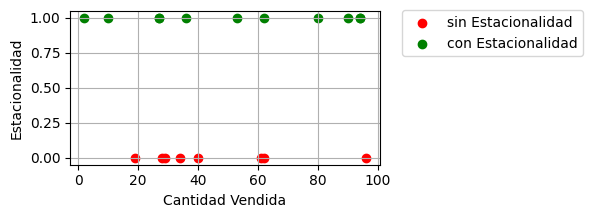

In [19]:
plt.rcParams['figure.figsize'] = [4,2] 
plt.xlabel("Cantidad Vendida")
plt.ylabel("Estacionalidad")

plt.scatter(Estacion[Estacion['Estacionalidad']==0]['CantidadVendida'],
            Estacion[Estacion['Estacionalidad']==0]['Estacionalidad'], 
            label='sin Estacionalidad', c='red')
plt.scatter(Estacion[Estacion['Estacionalidad']==1]['CantidadVendida'],
            Estacion[Estacion['Estacionalidad']==1]['Estacionalidad'], 
            label='con Estacionalidad', c='green')

plt.legend(bbox_to_anchor=(1.05, 1.05))
plt.grid()

<span style="color: green;">
<b>Prueba del Punto Biserial

In [20]:
pointbiserialr(Estacion['CantidadVendida'], Estacion['Estacionalidad'])

SignificanceResult(statistic=0.10361691152341637, pvalue=0.6729281999938851)

$\blacksquare$ Al igual que en el caso de Promoción-Descuento, la prueba Point-Biserial aplicada a la Estacionalidad nos da un valor de 0.67, lo cual no es suficiente para rechazar la hipótesis nula. <br>
<br>
Por lo tanto, podemos afirmar que no existe relación suficiente entre la Cantidad Vendida y la Estacionalidad.

## 2.5- Método de Pago

In [21]:
MetPago = T1P1[['CantidadVendida','MetodoPago']]

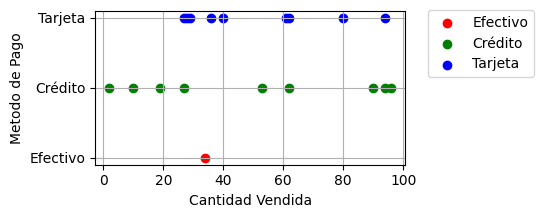

In [22]:
plt.xlabel("Cantidad Vendida")
plt.ylabel("Metodo de Pago")

plt.scatter(MetPago[MetPago['MetodoPago']=='Efectivo']['CantidadVendida'],
            MetPago[MetPago['MetodoPago']=='Efectivo']['MetodoPago'], 
            label='Efectivo', c='red')
plt.scatter(MetPago[MetPago['MetodoPago']=='Crédito']['CantidadVendida'],
            MetPago[MetPago['MetodoPago']=='Crédito']['MetodoPago'], 
            label='Crédito', c='green')
plt.scatter(MetPago[MetPago['MetodoPago']=='Tarjeta']['CantidadVendida'],
            MetPago[MetPago['MetodoPago']=='Tarjeta']['MetodoPago'], 
            label='Tarjeta', c='blue')

plt.legend(bbox_to_anchor=(1.05, 1.05))
plt.grid()

<span style="color: green;">
<b>Prueba de Kruskal-Wallis

In [23]:
G1 = MetPago[MetPago['MetodoPago']=='Efectivo']['CantidadVendida']
G2 = MetPago[MetPago['MetodoPago']=='Crédito']['CantidadVendida']
G3 = MetPago[MetPago['MetodoPago']=='Tarjeta']['CantidadVendida']

kruskal(G1,G2,G3)

KruskalResult(statistic=0.21987686895338523, pvalue=0.8958892894916454)

$\blacksquare$ La prueba de <b>Kruskal-Wallis</b> nos da un p-value de 0.89. Por lo cual no se puede rechazar la hipótesis nula y podremos afirmar que las muestras no presentan diferencias significativas entre si. Dicho de otra manera, el Método de Pago no influye en la Cantidad Vendida para el caso de esta Tienda.

## 2.6- Nivel de Inventario

In [24]:
Invent = T1P1[['CantidadVendida','NivelInventario']]
xii = Invent['CantidadVendida']
yii = Invent['NivelInventario']

xii = sm.add_constant(xii)
model = sm.OLS(yii,xii).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        NivelInventario   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.051
Method:                 Least Squares   F-statistic:                    0.1337
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.719
Time:                        16:46:08   Log-Likelihood:                -122.38
No. Observations:                  19   AIC:                             248.8
Df Residuals:                      17   BIC:                             250.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             174.1468     72.476      2.403      0.028      21.236     327.057
CantidadVendida    -0.4595      1.257     -0.366      0.719      -3.111       2.192
==============================================================================
Omnibus:                        5.818   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.055   Jarque-Bera (JB):                3.930
Skew:                           1.103   Prob(JB):                        0.140
Kurtosis:                       3.310   Cond. No.                         114.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

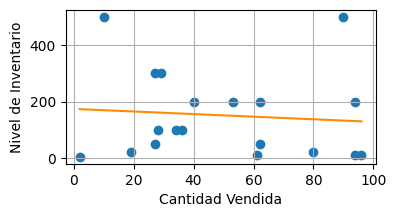

In [25]:
plt.rcParams['figure.figsize'] = [4,2] 
plt.xlabel("Cantidad Vendida")
plt.ylabel("Nivel de Inventario")
plt.scatter(Invent['CantidadVendida'], Invent['NivelInventario'])

a,b = Invent['CantidadVendida'].min(), Invent['CantidadVendida'].max()
plt.plot([a,b], 
         [ model.params[1]*a+model.params[0], 
           model.params[1]*b+model.params[0] ], 
         c='darkorange')
plt.grid()

$\blacksquare$ Además del coeficiente de correlación, la <b>$R^2$</b> de la Regresión Lineal anterior nos indica que la correlación entre la Cantidad Vendida y el Nivel de Inventario no es estadisticamente suficiente.

## GENERAL

In [26]:
Lista = [ 
          [
           'MOBO_'+str(i+1)+'_'+str(k+1) for k in range(Datos['ProductoId'].nunique())
          ] for i in range(Datos['TiendaId'].nunique()) 
        ]
Lista = np.array(Lista).flatten().tolist()

In [27]:
def Indicadores_Generales():

    W = []
    for t in Datos['TiendaId'].unique():
        for p in Datos['ProductoId'].unique():
            
            TP = Datos[ (Datos['TiendaId']==t) & (Datos['ProductoId']==p) ].sort_values(by='FechaVenta') 
            
            r1 = np.corrcoef(TP['CantidadVendida'], TP['PrecioUnitario'])[0,1]
            r2 = pointbiserialr(TP['CantidadVendida'], TP['PromocionDescuento'])[1]
            r3 = pointbiserialr(TP['CantidadVendida'], TP['Estacionalidad'])[1]

            G1 = TP[TP['MetodoPago']=='Efectivo']['CantidadVendida']
            G2 = TP[TP['MetodoPago']=='Crédito']['CantidadVendida']
            G3 = TP[TP['MetodoPago']=='Tarjeta']['CantidadVendida']            
            
            r4 = kruskal(G1,G2,G3)[1]
            r5 = np.corrcoef(TP['CantidadVendida'], TP['NivelInventario'])[0,1]

            W.append([r1,r2,r3,r4,r5])
    return(W)         


In [28]:
ig = Indicadores_Generales()
Mobo = pd.DataFrame(np.array(ig),
                    index=Lista, 
                    columns=['Cant-Precio','Cant-PromDesc','Cant-Estacion','Cant-Metod','Cant-Invent'])

In [29]:
Mobo.head()

,Cant-Precio,Cant-PromDesc,Cant-Estacion,Cant-Metod,Cant-Invent
MOBO_1_1,0.393980,0.554251,0.323939,0.463972,-0.061304
MOBO_1_2,-0.451207,0.879633,0.824400,0.373009,-0.141186
MOBO_1_3,-0.027437,0.392769,0.754780,0.808782,0.002948
MOBO_1_4,-0.261361,0.648788,0.197733,0.650108,-0.353920
MOBO_1_5,-0.148070,0.470240,0.443622,0.350605,-0.150679


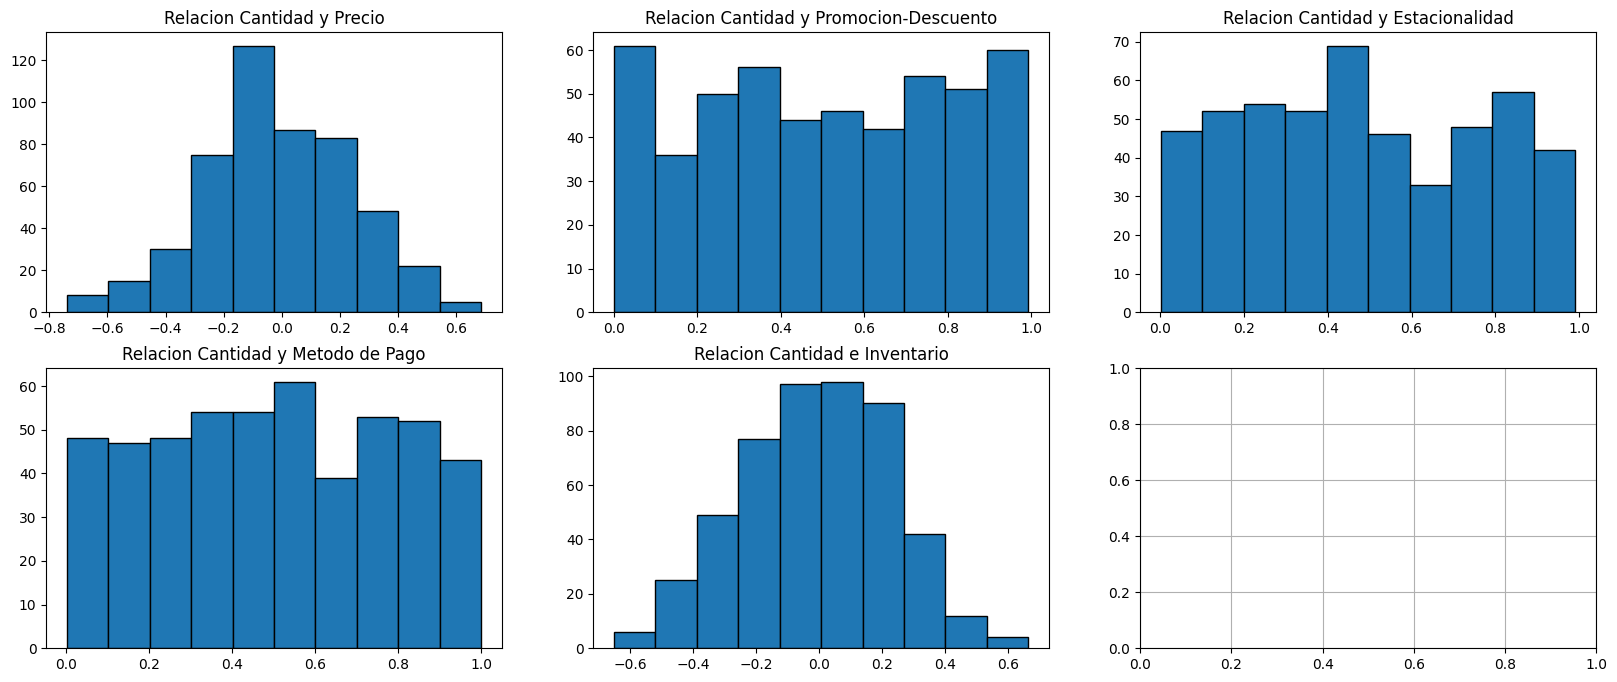

In [30]:
plt.rcParams['figure.figsize'] = [20,8] 

fig, ax = plt.subplots(2,3)

ax[0,0].hist(Mobo['Cant-Precio'],ec='black', bins=10)
ax[0,0].set_title('Relacion Cantidad y Precio')

ax[0,1].hist(Mobo['Cant-PromDesc'],ec='black', bins=10)
ax[0,1].set_title('Relacion Cantidad y Promocion-Descuento')

ax[0,2].hist(Mobo['Cant-Estacion'],ec='black', bins=10)
ax[0,2].set_title('Relacion Cantidad y Estacionalidad')

ax[1,0].hist(Mobo['Cant-Metod'],ec='black', bins=10)
ax[1,0].set_title('Relacion Cantidad y Metodo de Pago')

ax[1,1].hist(Mobo['Cant-Invent'],ec='black', bins=10)
ax[1,1].set_title('Relacion Cantidad e Inventario')

plt.grid()

$\blacksquare$ Las gráficas anteriores nos dan la distribución de la correlación de cada variable considerada con la variable objetivo : Cantidad Vendida. <br>
<br>
Podemos notar que, para las variables Precio e Inventario, solamente los <b>Bins</b> extremos nos dan una <b>correlación</b> arriba del valor de 0.5, lo cual puede ser suficiente para tomarse en cuenta en el caso de las Tiendas-Producto que caigan en dichos intervalos. <br>
<br>
Luego, para las variables Promoción-Descuento, Estacionalidad y Método de Pago, solamente el <b>Bin</b> izquierdo nos devuelve la cantidad de Tienda-Producto cuyo los <b>p-valor</b> es suficiente para hablar de una correlación con la variable Cantidad Vendida. <br>
<br>
De manera general, se descartaría la relevancia de las variables <i>Precio Unitario, Promocion-Descuento, Estacionalidad, Método de Pago e Inventario</i> para poder predecir más adelante el valor de la variable <i>Cantidad Vendida</i>, salvo en el caso contado de algunas Tiendas-Producto en donde la correlación es suficiente para tomarse en cuenta.

<span style="color: green;">
<b> Porcentaje significativo para cada Variable

In [96]:
Signif = [(Mobo['Cant-Precio'].abs()>0.5).sum(), 
          (Mobo['Cant-PromDesc']<0.05).sum(),
          (Mobo['Cant-Estacion']<0.05).sum(), 
          (Mobo['Cant-Metod']<0.05).sum(),
          (Mobo['Cant-Invent'].abs()>0.5).sum()]

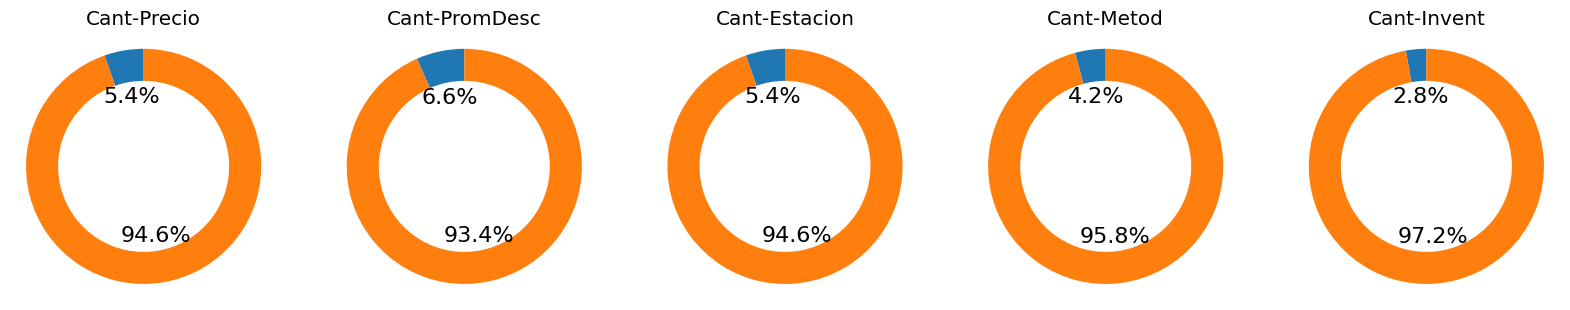

In [127]:
plt.rcParams['figure.figsize'] = [20,8] 
plt.rcParams.update({'font.size': 12}) 

fig, ax = plt.subplots(1,5)
for i,sO in enumerate(Signif):
    
    ax[i].pie([sO,500-sO], 
              radius=1.1, 
              autopct="%.1f%%", 
              wedgeprops={'width': 0.3}, 
              startangle=90, 
              textprops={'color': 'black', 'fontsize': 16})
    
    ax[i].set_title(Mobo.columns[i])


$\blacksquare$ Las gráficas de arriba nos muestran, por cada Variable Independiente, que proporción de los datos tiene una correlación significativa con la variable de interés llamada Cantidad Vendida. <br>
<br>
Por ejemplo, solamente un 6.6% de los datos son tales que se puede afirmar una correlación entre la Cantidad Vendida y las Promociones-Descuento.

<span style="color: green;">
<b> A veces las Promociones-Descuento se concentran más en el segmento de menor Cantidad Vendida

In [129]:
def Direccion_de_Variacion():
    W = []
    for t in Datos['TiendaId'].unique():
        for p in Datos['ProductoId'].unique():
            
            TP = Datos[ (Datos['TiendaId']==t) & (Datos['ProductoId']==p) ].sort_values(by='FechaVenta') 
            
            r2 = pointbiserialr(TP['CantidadVendida'], TP['PromocionDescuento'])[0]  # Recuperamos el valor del indicador
                                                                                     # y no el p-value
            r3 = pointbiserialr(TP['CantidadVendida'], TP['Estacionalidad'])[0]
            W.append([r2,r3])
    return(W)

In [137]:
dv = Direccion_de_Variacion()
Direk = pd.DataFrame(np.array(dv),
                     index=Lista, 
                     columns=['PromDesc','Estacion'])
DirekVar = [(Direk['PromDesc']<0).sum(), (Direk['Estacion']<0).sum()]

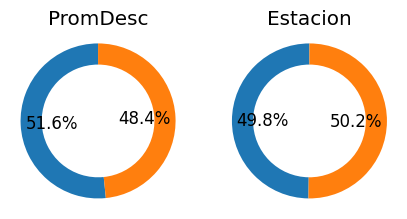

In [144]:
plt.rcParams['figure.figsize'] = [5,3] 
plt.rcParams.update({'font.size': 12}) 

fig, ax = plt.subplots(1,2)
for i,sO in enumerate(DirekVar):
    
    ax[i].pie([sO,500-sO], 
              radius=1.1, 
              autopct="%.1f%%", 
              wedgeprops={'width': 0.3}, 
              startangle=90, 
              textprops={'color': 'black', 'fontsize': 12})
    
    ax[i].set_title(Direk.columns[i])

$\blacksquare$ Las gráficas de pastel anteriores nos indican que por ejemplo el 51.6% de las Promociones-Descuento varian de manera inversamente proporcional a la Cantidad Vendida, mientras que para la variable relativa a la Estacionalidad este porcentaje es del 49.8%. <br>
<br>
En otras palabras, solo el 48.4% de incremento en las Promociones-Descuento causan un incremento en las Cantidades Vendidas, mientras que para el caso de la Estacionalidad, este porcentaje es del 50.2%.

<div class="alert alert-block alert-success">
<center><b>TIENDAS :</b></center>
</div>

# 3.- TIENDAS

## 3.1- Caracteristicas

<span style="color: green;">
<b>Creamos CARACTERISTICAS para poder agrupar las diferentes Tiendas

In [31]:
Datos['año'] = Datos['FechaVenta'].dt.year
Datos['mes'] = Datos['FechaVenta'].dt.month

<span style="color: green;">
<b> 1.- Cantidad de Unidades totales vendidas por año

In [32]:
Wtotal = Datos.pivot_table( index='TiendaId',
                       columns=['año'],
                       values='CantidadVendida',
                       aggfunc='sum' )
Wtotal.columns=[2022,2023]
Wtotal

,2022,2023
TiendaId,,
Tienda_1,25628,24726
Tienda_10,24938,24454
Tienda_2,25332,25055
Tienda_3,26814,25583
Tienda_4,27062,26336
Tienda_5,25004,23680
Tienda_6,24678,24483
Tienda_7,25638,26472
Tienda_8,26749,25198


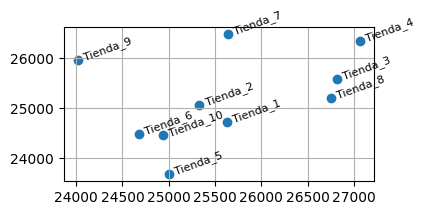

In [33]:
plt.rcParams['figure.figsize'] = [4,2] 
plt.scatter(Wtotal[2022],Wtotal[2023])

for i,tienda in enumerate(Wtotal.index):
    plt.annotate(tienda, 
                 xy =(Wtotal.iloc[i,0], Wtotal.iloc[i,1]), 
                 xytext=(Wtotal.iloc[i,0]+50, Wtotal.iloc[i,1]+0), 
                 fontsize=8, 
                 rotation=20
                )
plt.grid()

<span style="color: green;">
<b> 2.- Número de Evento de Compra registrado por año

In [34]:
Wtrans = Datos.pivot_table( index='TiendaId',
                       columns=['año'],
                       values='CantidadVendida',
                       aggfunc='count' )
Wtrans.columns=[2022,2023]
Wtrans

,2022,2023
TiendaId,,
Tienda_1,495,488
Tienda_10,495,500
Tienda_2,508,487
Tienda_3,513,496
Tienda_4,530,512
Tienda_5,513,481
Tienda_6,486,490
Tienda_7,493,507
Tienda_8,516,497


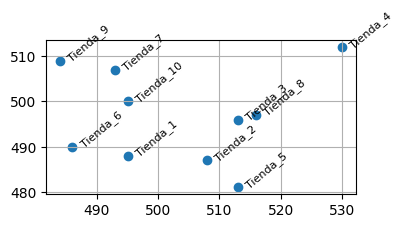

In [35]:
plt.rcParams['figure.figsize'] = [4,2] 
plt.scatter(Wtrans[2022],Wtrans[2023])

for i,tienda in enumerate(Wtrans.index):
    plt.annotate(tienda, 
                 xy =(Wtrans.iloc[i,0], Wtrans.iloc[i,1]), 
                 xytext=(Wtrans.iloc[i,0]+1, Wtrans.iloc[i,1]+0), 
                 fontsize=8, 
                 rotation=40
                )
plt.grid()

<span style="color: green;">
<b> 3.- Número de Promociones y/o Descuento registradas por año

In [36]:
Wprom = Datos.pivot_table( index='TiendaId',
                       columns=['año'],
                       values='PromocionDescuento',
                       aggfunc='sum' )
Wprom.columns=[2022,2023]
Wprom

,2022,2023
TiendaId,,
Tienda_1,245,243
Tienda_10,238,243
Tienda_2,257,238
Tienda_3,277,275
Tienda_4,268,256
Tienda_5,265,258
Tienda_6,247,229
Tienda_7,244,245
Tienda_8,254,261


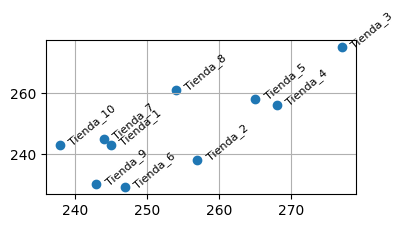

In [37]:
plt.rcParams['figure.figsize'] = [4,2] 
plt.scatter(Wprom[2022],Wprom[2023])

for i,tienda in enumerate(Wprom.index):
    plt.annotate(tienda, 
                 xy =(Wprom.iloc[i,0], Wprom.iloc[i,1]), 
                 xytext=(Wprom.iloc[i,0]+1, Wprom.iloc[i,1]+0), 
                 fontsize=8, 
                 rotation=40
                )
plt.grid()

<span style="color: green;">
<b> Juntamos en una sola Matriz de Caracteristicas las 3 matrices creadas anteriormente

In [38]:
W = pd.concat([Wtotal, Wtrans, Wprom],axis=1)
W.columns = ['UnitTot22', 'UnitTot23', 
             'NumComp22', 'NumComp23',
             'NumPromDesc22', 'NumPromDesc23']
W

,UnitTot22,UnitTot23,NumComp22,NumComp23,NumPromDesc22,NumPromDesc23
TiendaId,,,,,,
Tienda_1,25628,24726,495,488,245,243
Tienda_10,24938,24454,495,500,238,243
Tienda_2,25332,25055,508,487,257,238
Tienda_3,26814,25583,513,496,277,275
Tienda_4,27062,26336,530,512,268,256
Tienda_5,25004,23680,513,481,265,258
Tienda_6,24678,24483,486,490,247,229
Tienda_7,25638,26472,493,507,244,245
Tienda_8,26749,25198,516,497,254,261


## 3.2- Normalización

<span style="color: green;">
<b> Cambio de Escala : Normalizar

In [39]:
scaler = MinMaxScaler()

Wii = pd.DataFrame( scaler.fit_transform(W), 
                    columns = W.columns )
Wii.index = W.index
Wii

,UnitTot22,UnitTot23,NumComp22,NumComp23,NumPromDesc22,NumPromDesc23
TiendaId,,,,,,
Tienda_1,0.529219,0.374642,0.239130,0.225806,0.179487,0.304348
Tienda_10,0.302692,0.277221,0.239130,0.612903,0.000000,0.304348
Tienda_2,0.432042,0.492479,0.521739,0.193548,0.487179,0.195652
Tienda_3,0.918582,0.681590,0.630435,0.483871,1.000000,1.000000
Tienda_4,1.000000,0.951289,1.000000,1.000000,0.769231,0.586957
Tienda_5,0.324360,0.000000,0.630435,0.000000,0.692308,0.630435
Tienda_6,0.217334,0.287607,0.043478,0.290323,0.230769,0.000000
Tienda_7,0.532502,1.000000,0.195652,0.838710,0.153846,0.347826
Tienda_8,0.897242,0.543696,0.695652,0.516129,0.410256,0.695652


## 3.3- Cluster

<span style="color: green;">
<b> Clusterización

In [40]:
inercia = []
silhouette = []

for k in tqdm(range(2,10)):
    Kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    Kmeans.fit(Wii.values)
    inercia.append(Kmeans.inertia_)

    r = silhouette_score(Wii.values, Kmeans.labels_+1)
    silhouette.append(r)


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.75it/s]


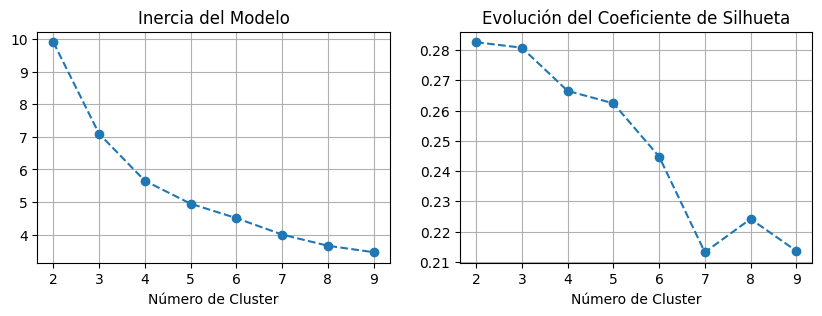

In [154]:
plt.rcParams['figure.figsize'] = [10,3]
#plt.rcParams.update({'font.size': 10}) 

fig, ax = plt.subplots(1,2)

ax[0].plot(range(2,10),inercia,linestyle='--', marker='o')
ax[0].set_title('Inercia del Modelo')
ax[0].set_xlabel('Número de Cluster')
ax[0].grid()

ax[1].plot(range(2,10),silhouette,linestyle='--', marker='o')
ax[1].set_title('Evolución del Coeficiente de Silhueta')
ax[1].set_xlabel('Número de Cluster')
ax[1].grid()

$\blacksquare$ Nos quedaremos entonces con el valor de 4 como el número de Clusters ideal.

## 3.4- Gráfica

In [42]:
W2 = Wii.copy()
Kmeans = KMeans(n_clusters=4, random_state=1, n_init=10)
Kmeans.fit(Wii.values)
W2['Cluster'] = Kmeans.labels_+1
W2

,UnitTot22,UnitTot23,NumComp22,NumComp23,NumPromDesc22,NumPromDesc23,Cluster
TiendaId,,,,,,,
Tienda_1,0.529219,0.374642,0.239130,0.225806,0.179487,0.304348,1
Tienda_10,0.302692,0.277221,0.239130,0.612903,0.000000,0.304348,1
Tienda_2,0.432042,0.492479,0.521739,0.193548,0.487179,0.195652,1
Tienda_3,0.918582,0.681590,0.630435,0.483871,1.000000,1.000000,2
Tienda_4,1.000000,0.951289,1.000000,1.000000,0.769231,0.586957,2
Tienda_5,0.324360,0.000000,0.630435,0.000000,0.692308,0.630435,4
Tienda_6,0.217334,0.287607,0.043478,0.290323,0.230769,0.000000,1
Tienda_7,0.532502,1.000000,0.195652,0.838710,0.153846,0.347826,3
Tienda_8,0.897242,0.543696,0.695652,0.516129,0.410256,0.695652,2


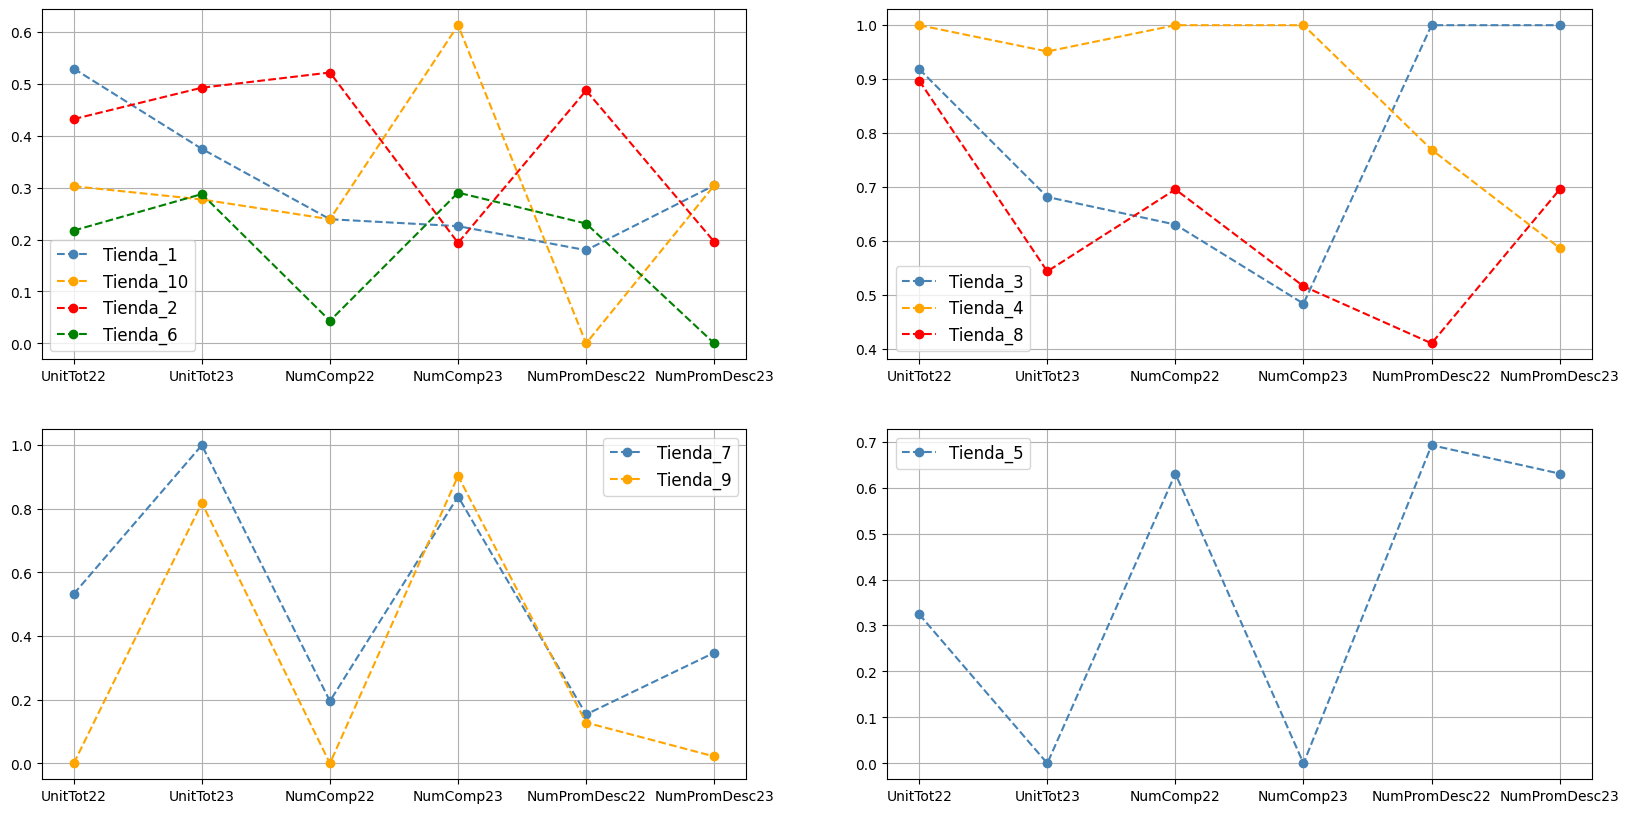

In [43]:
COLORES = ['steelblue','orange','red','green']
G1 = W2[W2['Cluster']==1]
G2 = W2[W2['Cluster']==2]
G3 = W2[W2['Cluster']==3]
G4 = W2[W2['Cluster']==4]

plt.rcParams['figure.figsize'] = [20,10] 
fig, ax = plt.subplots(2,2)

for i,k in enumerate(G1.index):
    ax[0,0].plot(G1.loc[k,:][:-1], linestyle='--', marker='o', label=k, c=COLORES[i])
    ax[0,0].legend(fontsize=12)
    ax[0,0].grid(True)

for i,k in enumerate(G2.index):
    ax[0,1].plot(G2.loc[k,:][:-1], linestyle='--', marker='o', label=k, c=COLORES[i])
    ax[0,1].legend(fontsize=12)
    ax[0,1].grid(True)

for i,k in enumerate(G3.index):
    ax[1,0].plot(G3.loc[k,:][:-1], linestyle='--', marker='o', label=k, c=COLORES[i])
    ax[1,0].legend(fontsize=12)
    ax[1,0].grid(True)

for i,k in enumerate(G4.index):
    ax[1,1].plot(G4.loc[k,:][:-1], linestyle='--', marker='o', label=k, c=COLORES[i])
    ax[1,1].legend(fontsize=12)
    ax[1,1].grid(True)


$\blacksquare$ Refiriéndonos a la gráfica anterior, podemos ver que el primer grupo de Tiendas tiende a estar por debajo del percentil 50 en todos sus indicadores, mientras que el grupo que le sigue (superior derecha) tienda a tener sus indicadores arriba del percentil 50. <br>
<br>
Por otra parte, la Tienda 5 está en un grupo por aparte ya que es la que presenta un comportamiento más distintivo.

<div class="alert alert-block alert-success">
<center><b>PRODUCTOS :</b></center>
</div>

# 4.- PRODUCTOS

## 4.1- Caracteristicas

<span style="color: green;">
<b> 1.- Cantidad de Unidades totales vendidas por año

In [44]:
Ztotal = Datos.pivot_table( index='ProductoId',
                            columns=['año'],
                            values='CantidadVendida',
                            aggfunc='sum' )
Ztotal.columns=[2022,2023]
Ztotal.head()

,2022,2023
ProductoId,,
Producto_1,5026,4774
Producto_10,5458,4897
Producto_11,4220,5707
Producto_12,5002,4908
Producto_13,5428,5083


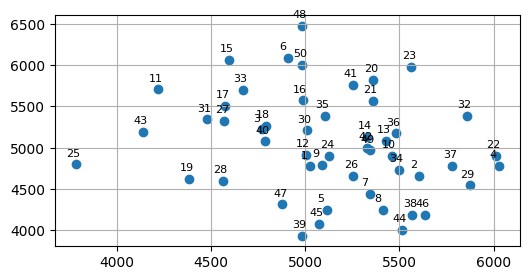

In [45]:
plt.rcParams['figure.figsize'] = [6,3] 
plt.scatter(Ztotal[2022],Ztotal[2023])

for i,producto in enumerate(Ztotal.index):
    producto = producto.split('_')[1]
    plt.annotate(producto, 
                 xy =(Ztotal.iloc[i,0], Ztotal.iloc[i,1]), 
                 xytext=(Ztotal.iloc[i,0]-50, Ztotal.iloc[i,1]+100), 
                 fontsize=8, 
                 rotation=0
                )
plt.grid()

<span style="color: green;">
<b> 2.- Número de Evento de Compra registrado por año

In [46]:
Ztrans = Datos.pivot_table( index='ProductoId',
                            columns=['año'],
                            values='CantidadVendida',
                            aggfunc='count' )
Ztrans.columns=[2022,2023]
Ztrans.head()

,2022,2023
ProductoId,,
Producto_1,97,97
Producto_10,114,98
Producto_11,93,106
Producto_12,95,90
Producto_13,104,109


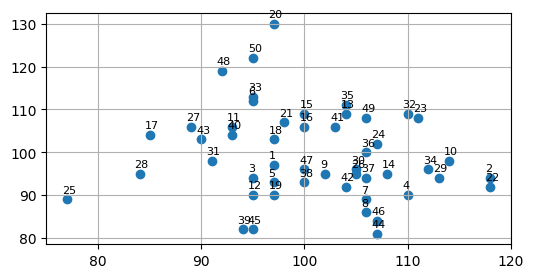

In [47]:
plt.rcParams['figure.figsize'] = [6,3] 
plt.scatter(Ztrans[2022],Ztrans[2023])

for i,producto in enumerate(Ztrans.index):
    producto = producto.split('_')[1]
    plt.annotate(producto, 
                 xy =(Ztrans.iloc[i,0], Ztrans.iloc[i,1]), 
                 xytext=(Ztrans.iloc[i,0]-0.5, Ztrans.iloc[i,1]+1.5), 
                 fontsize=8, 
                 rotation=0
                )
plt.grid()

<span style="color: green;">
<b> 3.- Número de Promociones y/o Descuento registradas por año

In [48]:
Zprom = Datos.pivot_table( index='ProductoId',
                       columns=['año'],
                       values='PromocionDescuento',
                       aggfunc='sum' )
Zprom.columns=[2022,2023]
Zprom.head()

,2022,2023
ProductoId,,
Producto_1,46,47
Producto_10,61,48
Producto_11,41,54
Producto_12,46,45
Producto_13,54,61


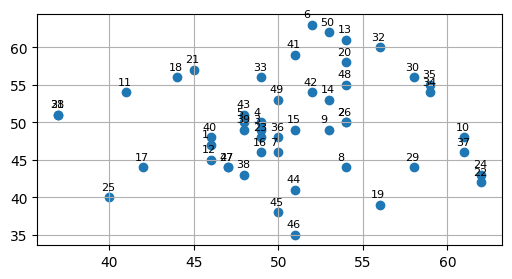

In [49]:
plt.rcParams['figure.figsize'] = [6,3] 
plt.scatter(Zprom[2022],Zprom[2023])

for i,producto in enumerate(Zprom.index):
    producto = producto.split('_')[1]
    plt.annotate(producto, 
                 xy =(Zprom.iloc[i,0], Zprom.iloc[i,1]), 
                 xytext=(Zprom.iloc[i,0]-0.5, Zprom.iloc[i,1]+1), 
                 fontsize=8, 
                 rotation=0
                )
plt.grid()

<span style="color: green;">
<b> Juntamos en una sola Matriz de Caracteristicas las 3 matrices creadas anteriormente

In [50]:
Z = pd.concat([Ztotal, Ztrans, Zprom],axis=1)
Z.columns = ['UnitTot22', 'UnitTot23', 
             'NumComp22', 'NumComp23',
             'NumPromDesc22', 'NumPromDesc23']
Z.head()

,UnitTot22,UnitTot23,NumComp22,NumComp23,NumPromDesc22,NumPromDesc23
ProductoId,,,,,,
Producto_1,5026,4774,97,97,46,47
Producto_10,5458,4897,114,98,61,48
Producto_11,4220,5707,93,106,41,54
Producto_12,5002,4908,95,90,46,45
Producto_13,5428,5083,104,109,54,61


## 4.2- Normalización

<span style="color: green;">
<b> Cambio de Escala : Normalizar

In [51]:
scaler = MinMaxScaler()

Zii = pd.DataFrame( scaler.fit_transform(Z), 
                    columns = Z.columns )
Zii.index = Z.index
Zii.head()

,UnitTot22,UnitTot23,NumComp22,NumComp23,NumPromDesc22,NumPromDesc23
ProductoId,,,,,,
Producto_1,0.554120,0.330848,0.487805,0.326531,0.36,0.428571
Producto_10,0.746548,0.379121,0.902439,0.346939,0.96,0.464286
Producto_11,0.195100,0.697017,0.390244,0.510204,0.16,0.678571
Producto_12,0.543430,0.383438,0.439024,0.183673,0.36,0.357143
Producto_13,0.733185,0.452119,0.658537,0.571429,0.68,0.928571


## 4.3- Cluster

<span style="color: green;">
<b> Clusterización

In [52]:
inercia = []
silhouette = []

for k in tqdm(range(2,10)):
    Kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    Kmeans.fit(Zii.values)
    inercia.append(Kmeans.inertia_)

    r = silhouette_score(Zii.values, Kmeans.labels_+1)
    silhouette.append(r)


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 18.69it/s]


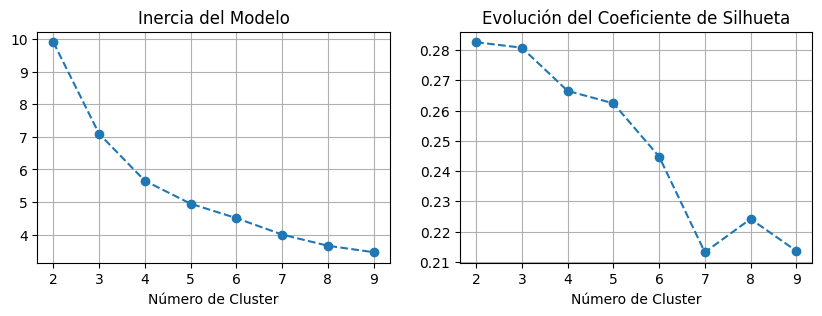

In [53]:
plt.rcParams['figure.figsize'] = [10,3] 
fig, ax = plt.subplots(1,2)

ax[0].plot(range(2,10),inercia,linestyle='--', marker='o')
ax[0].set_title('Inercia del Modelo')
ax[0].set_xlabel('Número de Cluster')
ax[0].grid()

ax[1].plot(range(2,10),silhouette,linestyle='--', marker='o')
ax[1].set_title('Evolución del Coeficiente de Silhueta')
ax[1].set_xlabel('Número de Cluster')
ax[1].grid()

## 4.4.- Gráfica

In [54]:
Z2 = Zii.copy()
Kmeans = KMeans(n_clusters=4, random_state=1, n_init=10)
Kmeans.fit(Zii.values)
Z2['Cluster'] = Kmeans.labels_+1
Z2.head()

,UnitTot22,UnitTot23,NumComp22,NumComp23,NumPromDesc22,NumPromDesc23,Cluster
ProductoId,,,,,,,
Producto_1,0.554120,0.330848,0.487805,0.326531,0.36,0.428571,4
Producto_10,0.746548,0.379121,0.902439,0.346939,0.96,0.464286,3
Producto_11,0.195100,0.697017,0.390244,0.510204,0.16,0.678571,1
Producto_12,0.543430,0.383438,0.439024,0.183673,0.36,0.357143,4
Producto_13,0.733185,0.452119,0.658537,0.571429,0.68,0.928571,2


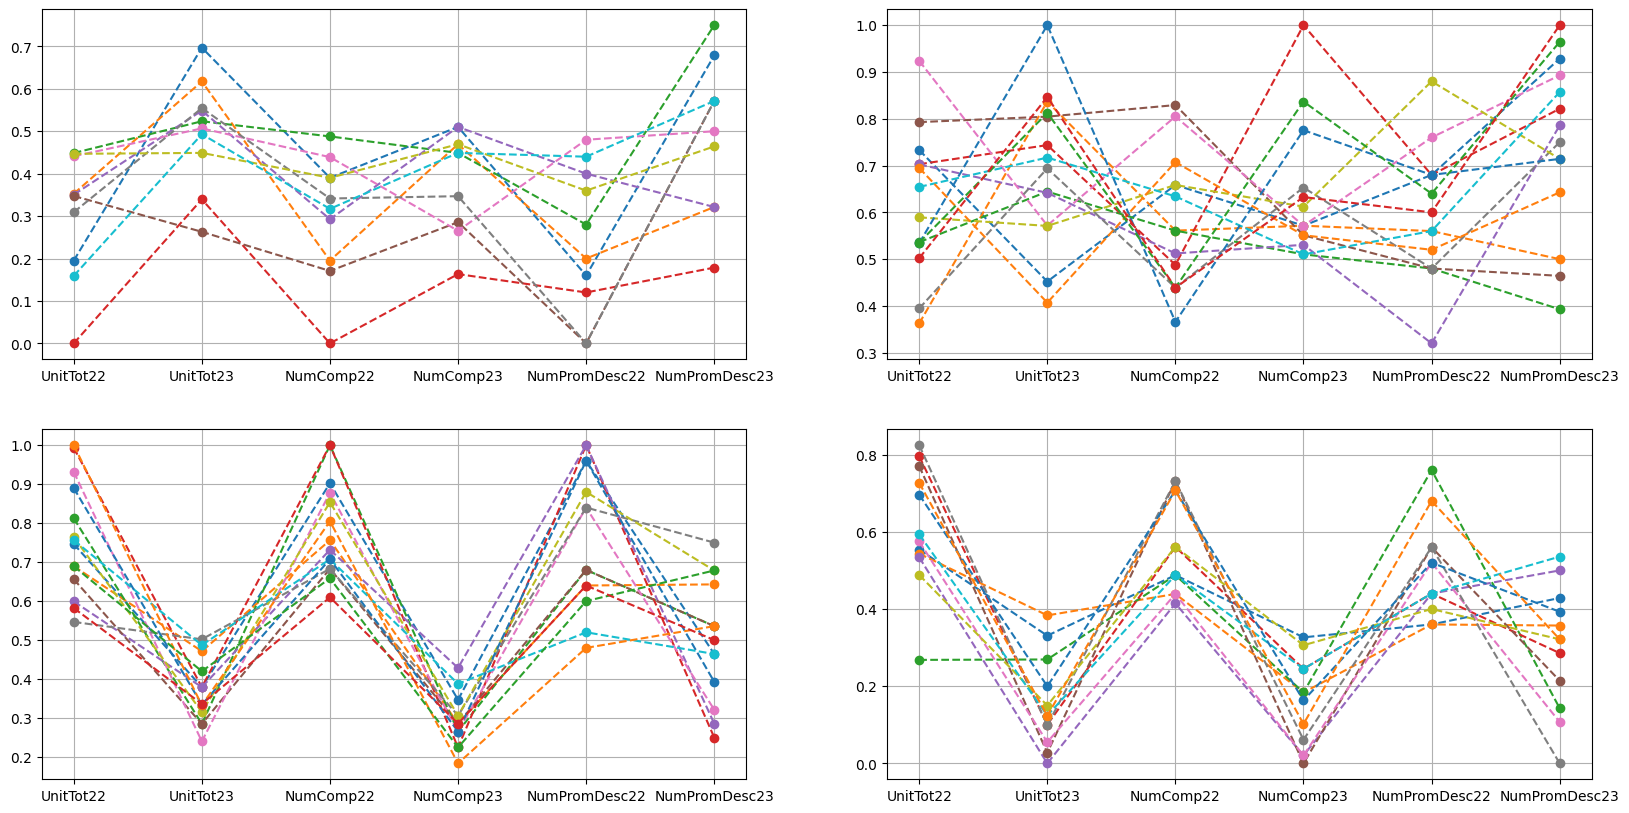

In [55]:
#COLORES = ['steelblue','orange','red','green']
G1 = Z2[Z2['Cluster']==1]
G2 = Z2[Z2['Cluster']==2]
G3 = Z2[Z2['Cluster']==3]
G4 = Z2[Z2['Cluster']==4]

plt.rcParams['figure.figsize'] = [20,10] 
fig, ax = plt.subplots(2,2)

for i,k in enumerate(G1.index):
    ax[0,0].plot(G1.loc[k,:][:-1], linestyle='--', marker='o', label=k)
    #ax[0,0].legend(fontsize=12, bbox_to_anchor=(1,1))
    ax[0,0].grid(True)

for i,k in enumerate(G2.index):
    ax[0,1].plot(G2.loc[k,:][:-1], linestyle='--', marker='o', label=k)
    #ax[0,1].legend(fontsize=12, bbox_to_anchor=(1,1))
    ax[0,1].grid(True)

for i,k in enumerate(G3.index):
    ax[1,0].plot(G3.loc[k,:][:-1], linestyle='--', marker='o', label=k)
    #ax[1,0].legend(fontsize=12, bbox_to_anchor=(1,1))
    ax[1,0].grid(True)

for i,k in enumerate(G4.index):
    ax[1,1].plot(G4.loc[k,:][:-1], linestyle='--', marker='o', label=k)
    #ax[1,1].legend(fontsize=12, bbox_to_anchor=(1,1))
    ax[1,1].grid(True)

<div class="alert alert-block alert-success">
<center><b>PREDICCIÓN :</b></center>
</div>

# 5.- PREDICCION

## 5.0- Granularidad : Tienda - Producto

<span style="color: green;">
<b> Tomamos la Serie conformada por el historial de Cantidad Vendida para la Tienda 01 y Producto 01.

In [56]:
Data = Datos[ (Datos['TiendaId']=='Tienda_1') & (Datos['ProductoId']=='Producto_1') ].sort_values(by='FechaVenta')

xO = Data[['FechaVenta', 'CantidadVendida']]
xO.set_index('FechaVenta', drop=True, inplace=True)
xO.head()

,CantidadVendida
FechaVenta,
2022-02-05,2
2022-03-26,90
2022-04-18,94
2022-04-26,53
2022-06-11,29


<span style="color: green;">
<b> Completamos los dias que no figuran llenándolos con el valor nulo

In [57]:
yO = xO.resample('D').sum().reindex(pd.date_range('2022-01-01', '2023-12-31', freq='D')).fillna(0)
yO = yO['CantidadVendida']  # Convertir a una Serie
yO.head()

2022-01-01    0.0
2022-01-02    0.0
2022-01-03    0.0
2022-01-04    0.0
2022-01-05    0.0
Freq: D, Name: CantidadVendida, dtype: float64

## 5.1- Matriz de Caracteristicas

In [58]:
M = pd.DataFrame( yO.values, 
                  index=yO.index, 
                  columns=['Y'] )

In [59]:
A = yO.to_numpy().flatten().tolist()

M['dia'] = M.index.day              # cifra para el dia de la Semana = 1, ... ,31 
M['mes'] = M.index.month
M['año'] = M.index.year

M['diaSemana'] = M.index.weekday    # nombre del dia de la Semana = Lunes, ... ,Domingo
M['CantidadCerosUltimos7Dias'] = [ A[max(0,i-7): max(0,i)].count(0) for i in range(len(A)) ]
M['NumeroDiasDesdeUltimaVenta'] = np.array([ i-np.where(np.array(A[:i])!=0)[0][-1] if i>np.where(np.array(A)!=0)[0][0] else i+1 for i in range(len(A))])
M['CantidadTotalVentaUltimos7Dias'] = [ np.array(A[max(0,i-7): max(0,i)]).sum() for i in range(len(A)) ]


In [60]:
M.head()

,Y,dia,mes,año,diaSemana,CantidadCerosUltimos7Dias,NumeroDiasDesdeUltimaVenta,CantidadTotalVentaUltimos7Dias
2022-01-01,0.0,1,1,2022,5,0,1,0.0
2022-01-02,0.0,2,1,2022,6,1,2,0.0
2022-01-03,0.0,3,1,2022,0,2,3,0.0
2022-01-04,0.0,4,1,2022,1,3,4,0.0
2022-01-05,0.0,5,1,2022,2,4,5,0.0


## 5.2- Mejor Modelo

In [68]:
def miPrediccion(xgb_reg,n):
    # prediccion para los proximos (n) dias
    Hist = A.copy()
    
    for tO in pd.date_range( start='2024-01-01', freq='D', periods=n ):
        r1 = Hist[-7:].count(0)
        r2 = Hist[-30:].count(0)
        r3 = len(Hist) - np.where(np.array(Hist)!=0)[0][-1]        
        r4 = np.sum(Hist[-7:])
        r5 = np.sum(Hist[-30:])
        caracteristicas = [tO.day,tO.month,tO.year,tO.weekday(),r1,r3,r4]

        pred = xgb_reg.predict(np.array([caracteristicas]))
        pred = np.abs(np.floor(pred))
        pred = pred[0]
        Hist.append(pred)
    return(Hist)

In [62]:
def Mejor_Modelo():
    Dikt = {}

    #---------- Parametros para la Evaluacion del Modelo --------#
    Zero_2022  = yO['2022'].tolist().count(0)
    Zero_2023  = yO['2023'].tolist().count(0)
    Venta_2022 = yO['2022'].sum()
    Venta_2023 = yO['2023'].sum()

    Zero_prom  = np.mean([Zero_2022,Zero_2023])
    Venta_prom = np.mean([Venta_2022,Venta_2023])
    #-------------------------------------------------------------#
    
    for mO in tqdm([1,2,3,4,5,6,7,8,9,10]):
        for nO in tqdm([1,2,3,4,5,6,7,8,9,10]):
            
            xgb_Regressor = xgb.XGBRegressor( max_depth    = mO,
                                              n_estimators = nO )
            xgb_Regressor.fit( M[M.columns[1:]], M['Y'] )
            
            pred = miPrediccion(xgb_Regressor,730)[-730:]
            pred = pd.Series(pred,index=pd.date_range(start='2024-01-01', freq='D', periods=730))
                            
            w1 = pred['2024'].tolist().count(0)
            w2 = pred['2025'].tolist().count(0)
            w3 = pred['2024'].sum()
            w4 = pred['2025'].sum()
            wO = 0.9*np.abs(Zero_prom-w1)/Zero_prom + 0.1*np.abs(Venta_prom-w3)/Venta_prom  ### Evaluar
            
            Dikt[str(mO)+'-'+str(nO)] = [w1,w2,w3,w4,wO]
    return(Dikt)

In [63]:
Dikt = Mejor_Modelo()

100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [27:49<00:00, 166.92s/it]


In [64]:
Result = pd.DataFrame(Dikt, index=['Zero_2024','Zero_2025','Venta_2024','Venta_2025','Evaluacion']).T
#Result.head()

In [65]:
Result.sort_values(by='Evaluacion', ascending=True)

,Zero_2024,Zero_2025,Venta_2024,Venta_2025,Evaluacion
10-6,337.0,331.0,350.0,226.0,0.072683
10-7,333.0,324.0,382.0,256.0,0.076030
10-2,356.0,351.0,93.0,107.0,0.081562
10-5,337.0,333.0,304.0,210.0,0.082429
10-1,357.0,359.0,75.0,33.0,0.087908
...,...,...,...,...,...
1-8,0.0,0.0,366.0,364.0,0.922458
1-7,0.0,0.0,366.0,364.0,0.922458
1-6,0.0,0.0,366.0,364.0,0.922458
1-5,0.0,0.0,366.0,364.0,0.922458


$\blacksquare$ Podemos apreciar que el mejor modelo en este caso sería el que tiene la combinación de parámetros 10-6, ya que es en donde la evaluacion es menor con un valor de 0.07

## 5.3- Predicción

In [79]:
XGBreg = xgb.XGBRegressor( max_depth=10,
                           n_estimators=6 )
XGBreg.fit( M[M.columns[1:]], M['Y'] )

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [80]:
Predik = miPrediccion(XGBreg,730)[-730:]
Predik = pd.Series(Predik,
                   index=pd.date_range( start='2024-01-01', freq='D', periods=730))
Predik.head()

2024-01-01    0.0
2024-01-02    0.0
2024-01-03    0.0
2024-01-04    0.0
2024-01-05    0.0
Freq: D, dtype: float32

## 5.4- Gráfica

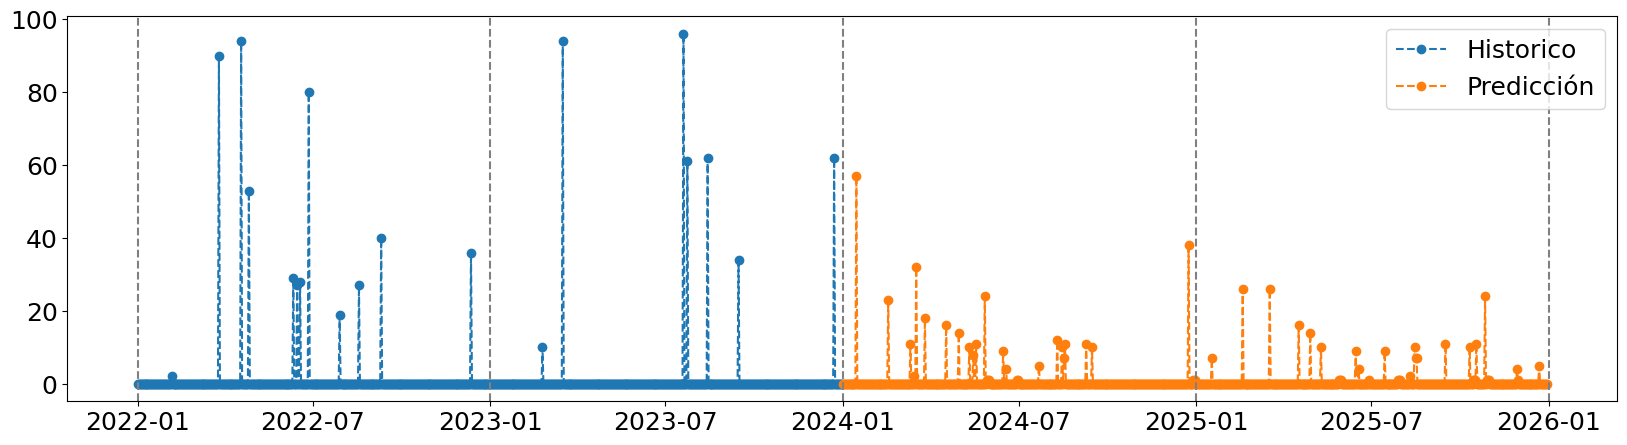

In [81]:
plt.rcParams['figure.figsize'] = [20,5] 
plt.rcParams.update({'font.size': 18}) 

plt.plot(yO.index,yO.values,linestyle='--',marker='o', label='Historico')
plt.plot(Predik.index, Predik.values,linestyle='--',marker='o', label='Predicción')

plt.axvline(x=pd.to_datetime('2022-01-01'), color='grey', linestyle='--')
plt.axvline(x=pd.to_datetime('2023-01-01'), color='grey', linestyle='--')
plt.axvline(x=pd.to_datetime('2024-01-01'), color='grey', linestyle='--')
plt.axvline(x=pd.to_datetime('2025-01-01'), color='grey', linestyle='--')
plt.axvline(x=pd.to_datetime('2026-01-01'), color='grey', linestyle='--')

plt.legend()

## 5.5- Importancia de Variables

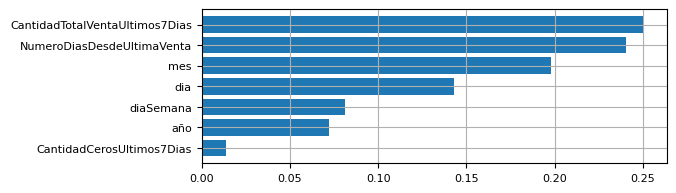

In [86]:
plt.rcParams['figure.figsize'] = [6,2]

Fo = {i:XGBreg.feature_importances_[n] for n,i in enumerate(M.columns[1:])}
Fo_sort = dict(sorted(Fo.items(), key=lambda item: item[1], reverse=False))

plt.barh(Fo_sort.keys(), Fo_sort.values())
plt.xticks(fontsize=8) 
plt.yticks(fontsize=8)
plt.grid()

## GENERAL